In [1]:
%run Librerias.ipynb

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
epochs=10

In [3]:
train_dir_15_aug = r"C:\Datasets\imagenes_como_vienen\15%\dataset_train_jpg_aug"
test_dir_15_aug  = r"C:\Datasets\imagenes_como_vienen\15%\dataset_test_jpg"

In [4]:
train_ds_m5 = tf.keras.utils.image_dataset_from_directory(
    train_dir_15_aug,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 39667 files belonging to 3 classes.


In [5]:
test_ds_m5 = tf.keras.utils.image_dataset_from_directory(
    test_dir_15_aug,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 9574 files belonging to 3 classes.


In [6]:
output_produccion  = "C:\\Datasets\\imagenes_como_vienen\\15%\\dataset_produccion_jpg"

In [7]:
produccion_ds = tf.keras.utils.image_dataset_from_directory(
    output_produccion,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 6000 files belonging to 3 classes.


In [8]:
from tensorflow import keras

model_m5 = keras.models.load_model("hongos_m5.keras")

In [9]:
loss_prod, acc_prod = model_m5.evaluate(produccion_ds)

188/188 ━━━━━━━━━━━━━━━━━━━━ 92s 454ms/step - accuracy: 0.4328 - loss: 1.3525


In [10]:
y_true = []
y_pred = []

for imagenes, etiquetas in produccion_ds:

    predicciones = model_m5.predict(imagenes, verbose=0)

    y_true.extend(etiquetas.numpy())

    y_pred.extend(np.argmax(predicciones, axis=1))

In [11]:
report_prod = classification_report(
    y_true,
    y_pred,
    target_names=produccion_ds.class_names,
    output_dict=True
)

In [12]:
df_prod = pd.DataFrame(report_prod).transpose()

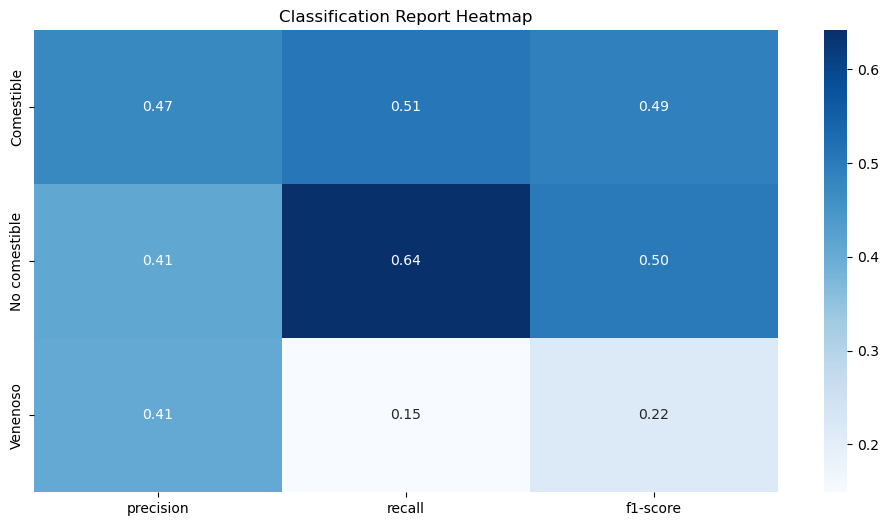

In [13]:
plt.figure(figsize=(12,6))
sns.heatmap(df_prod[['precision', 'recall', 'f1-score']].head(3), annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()

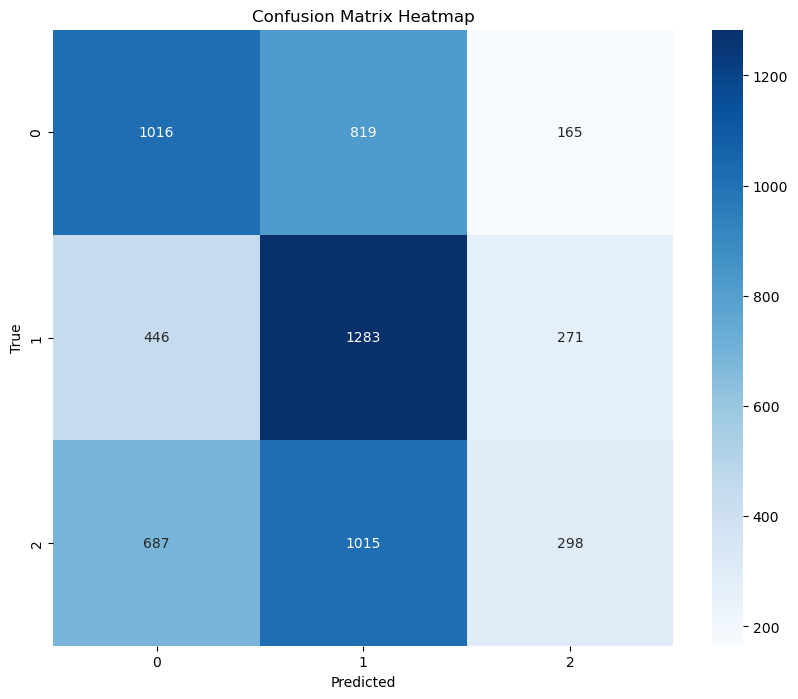

In [14]:
cm = confusion_matrix(y_true, y_pred)

# Graficar heatmap con enteros
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap="Blues", cbar=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()